In [15]:
# Análisis de datos bancarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("análisis exploratorio en proceso...")

análisis exploratorio en proceso...


In [16]:
# Cargar los 4 datasets
clientes = pd.read_csv('../../data/raw/clientes.csv')
productos = pd.read_csv('../../data/raw/productos_cliente.csv')
transacciones = pd.read_csv('../../data/raw/transacciones.csv')
canales = pd.read_csv('../../data/raw/uso_canales_digitales.csv')

print("Datos cargados exitosamente")
print(f"\nclientes: {clientes.shape[0]:,} filas x {clientes.shape[1]} columnas")
print(f"productos: {productos.shape[0]:,} filas x {productos.shape[1]} columnas")
print(f"transacciones: {transacciones.shape[0]:,} filas x {transacciones.shape[1]} columnas")
print(f"canales: {canales.shape[0]:,} filas x {canales.shape[1]} columnas")

Datos cargados exitosamente

clientes: 5,000 filas x 7 columnas
productos: 12,369 filas x 3 columnas
transacciones: 100,000 filas x 6 columnas
canales: 200,000 filas x 5 columnas



ESTADÍSTICAS DE CLIENTES
------------------------------

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cliente_id       5000 non-null   int64  
 1   edad             5000 non-null   int64  
 2   genero           5000 non-null   object 
 3   ubicacion        4908 non-null   float64
 4   antiguedad_dias  5000 non-null   int64  
 5   segmento         5000 non-null   object 
 6   ingreso_mensual  5000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 273.6+ KB

Estadísticas descriptivas:


,cliente_id,edad,genero,ubicacion,antiguedad_dias,segmento,ingreso_mensual
count,5000.000000,5000.000000,5000,4908.000000,5000.000000,5000,5000.000000
unique,NaN,NaN,2,NaN,NaN,4,NaN
top,NaN,NaN,F,NaN,NaN,Masivo,NaN
freq,NaN,NaN,2592,NaN,NaN,3849,NaN
mean,2500.500000,49.194400,NaN,911.887327,923.446600,NaN,20235.960000
std,1443.520003,17.918851,NaN,523.332107,523.211222,NaN,19338.572619
min,1.000000,18.000000,NaN,1.000000,1.000000,NaN,6000.000000
25%,1250.750000,34.000000,NaN,467.000000,477.000000,NaN,10600.000000
50%,2500.500000,49.000000,NaN,912.000000,938.000000,NaN,13200.000000
75%,3750.250000,65.000000,NaN,1366.000000,1368.250000,NaN,17600.000000



Distribución por segmento:


segmento
Masivo     3849
Alto        474
Medio       370
Premium     307
Name: count, dtype: int64

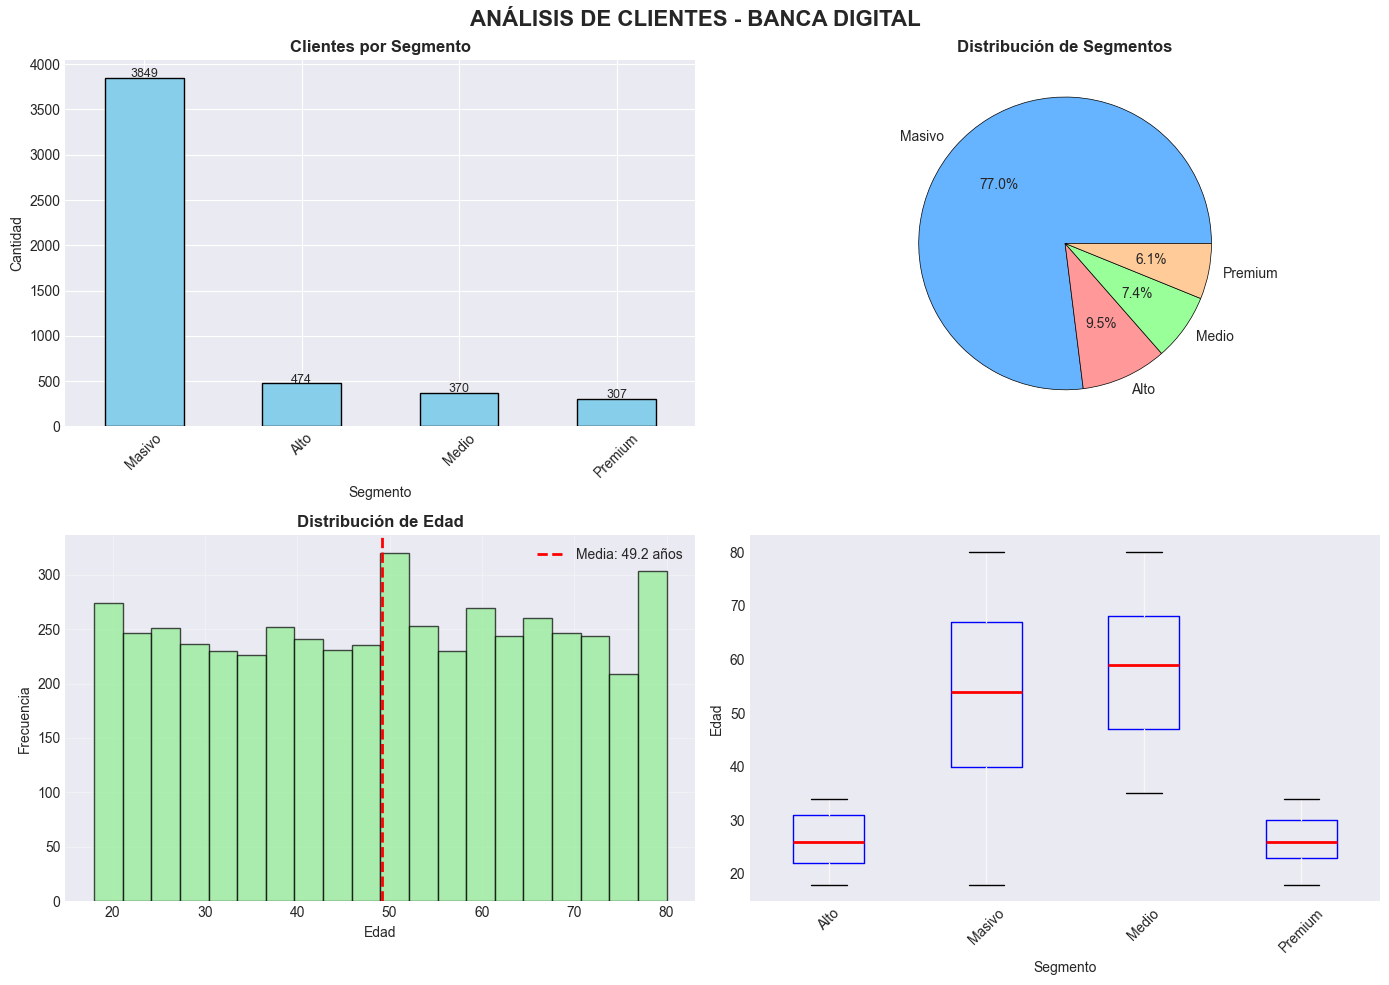

In [20]:
# Análisis de clientes

print("\nESTADÍSTICAS DE CLIENTES")
print("-" * 30)

# Información general
print("\nInfo del dataset:")
clientes.info()

print("\nEstadísticas descriptivas:")
display(clientes.describe(include='all'))

print("\nDistribución por segmento:")
segmento_counts = clientes['segmento'].value_counts()
display(segmento_counts)

# FIGURA ÚNICA: 4 gráficos en una cuadrícula 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# ---- Gráfico 1: Barras (Clientes por Segmento) ----
segmento_counts.plot(kind='bar', ax=axs[0, 0], color='skyblue', edgecolor='black')
axs[0, 0].set_title('Clientes por Segmento', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Segmento')
axs[0, 0].set_ylabel('Cantidad')
axs[0, 0].tick_params(axis='x', rotation=45)

# Valores encima de las barras
for i, v in enumerate(segmento_counts.values):
    axs[0, 0].text(i, v + 5, str(v), ha='center', fontsize=9)

# ---- Gráfico 2: Pastel (Distribución de Segmentos) ----
segmento_counts.plot(kind='pie', ax=axs[0, 1], autopct='%1.1f%%',
                     colors=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99'],
                     wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axs[0, 1].set_title('Distribución de Segmentos', fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel('')

# ---- Gráfico 3: Histograma de Edad ----
axs[1, 0].hist(clientes['edad'].dropna(), bins=20, edgecolor='black',
               color='lightgreen', alpha=0.7)
axs[1, 0].set_title('Distribución de Edad', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Edad')
axs[1, 0].set_ylabel('Frecuencia')
axs[1, 0].grid(True, alpha=0.3)

# Línea de la media
media_edad = clientes['edad'].mean()
axs[1, 0].axvline(media_edad, color='red', linestyle='--', linewidth=2,
                  label=f'Media: {media_edad:.1f} años')
axs[1, 0].legend()

# ---- Gráfico 4: Boxplot por Segmento ----
clientes.boxplot(column='edad', by='segmento', ax=axs[1, 1], grid=False,
                 boxprops=dict(color='blue'),
                 medianprops=dict(color='red', linewidth=2))
axs[1, 1].set_title('Edad por Segmento', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Segmento')
axs[1, 1].set_ylabel('Edad')
axs[1, 1].tick_params(axis='x', rotation=45)
axs[1, 1].set_title('')  # Quitar título automático de "by"

# ---- Ajustes finales ----
plt.suptitle('ANÁLISIS DE CLIENTES - BANCA DIGITAL', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


Análisis de productos por cliente

Top productos:


producto
cuenta_nomina        4654
cuenta_ahorro        2433
tarjeta_credito      2196
prestamo_personal    1485
seguro_vida           989
inversion             612
Name: count, dtype: int64

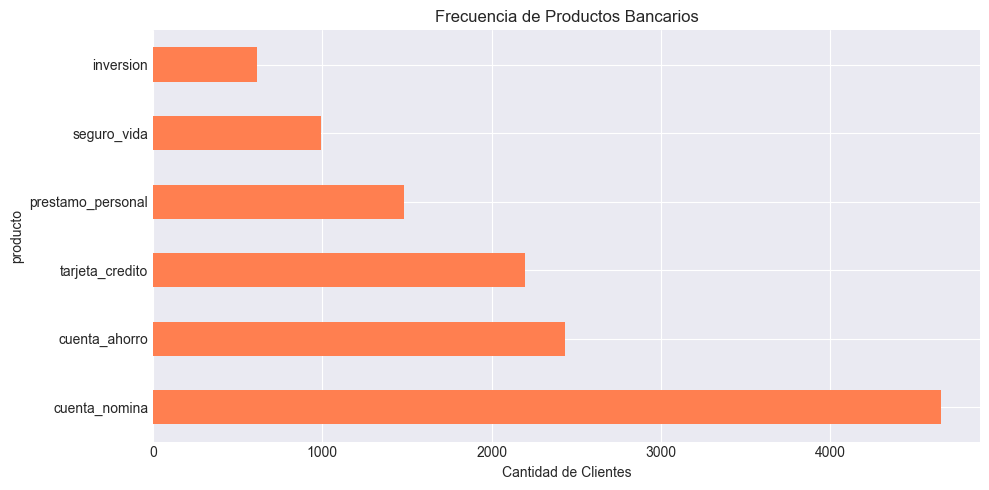


Productos por segmento:


segmento,Alto,Masivo,Medio,Premium
producto,,,,
cuenta_ahorro,399,1623,141,270
cuenta_nomina,443,3652,268,291
inversion,220,101,32,259
prestamo_personal,369,807,116,193
seguro_vida,358,288,60,283
tarjeta_credito,432,1302,182,280


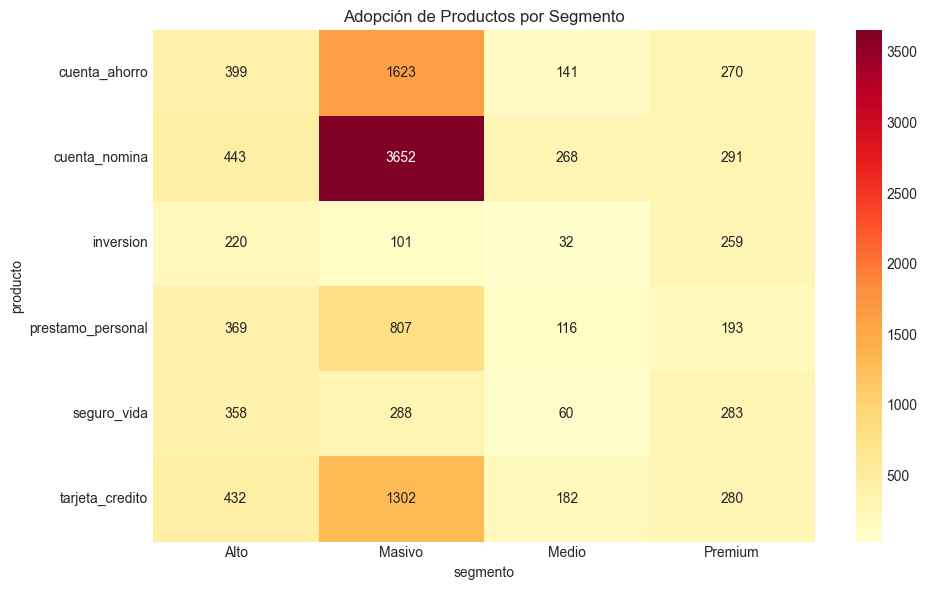

In [21]:
# Análisis por producto
print("\nAnálisis de productos por cliente")

# Productos más comunes
productos_top = productos['producto'].value_counts()
print("\nTop productos:")
display(productos_top)

plt.figure(figsize=(10, 5))
# Gráfico de barras horizontales: productos más populares (de mayor a menor)
# Cuando los nombres de productos son largos y no caben verticalmente
productos_top.plot(kind='barh', color='coral')
plt.title('Frecuencia de Productos Bancarios')
plt.xlabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()

# merge (fusión) la tabla de productos con la tabla de clientes
# left: se queda con TODOS los productos (aunque algún cliente no exista en la tabla clientes)
# on='cliente_id': columna clave para hacer la unión
# resultado: cada producto ahora tiene el segmento del cliente que lo compró
clientes_productos = pd.merge(
    productos,
    clientes[['cliente_id','segmento']], # Solo traemos las columnas necesarias
    on='cliente_id',
    how='left' # left = prioriza la tabla de productos (izquierda)
)

productos_segmento = pd.crosstab(
    clientes_productos['producto'],
    clientes_productos['segmento']
)

print("\nProductos por segmento:")
display(productos_segmento)

# Heatmap de productos vs segmento, producto preferido por segmento de clientes
# Colores más intensos: mayor cantidad de clientes usan este producto
# Colores más claros: menor cantidad de uso
plt.figure(figsize=(10, 6))
# annot:  mostrar número en cada celda (True)
# fmt: formato de número entero ('d')
# cmap: escala de colores ('YlOrRd')
sns.heatmap(productos_segmento, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Adopción de Productos por Segmento')
plt.tight_layout()
plt.show()


 Análisis de transacciones

Estadísticas de montos:


count    100000.000000
mean       1503.825639
std         792.260067
min       -3926.770000
25%         952.700000
50%        1496.485000
75%        2039.110000
max        5255.580000
Name: monto, dtype: float64


Valores nulos en canal: 990
Transacciones con monto negativo: 499
Fechas no parseables: 1,489


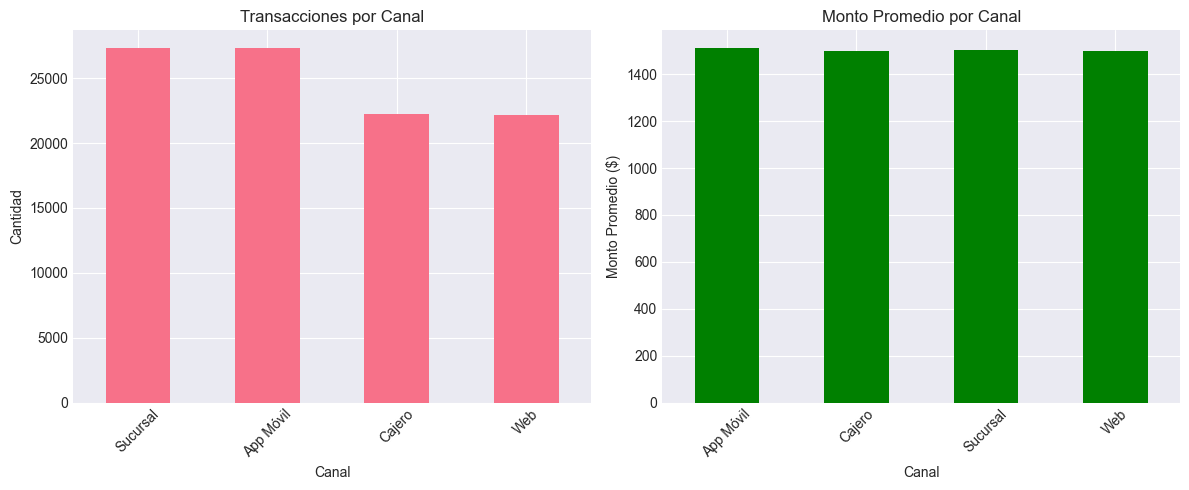

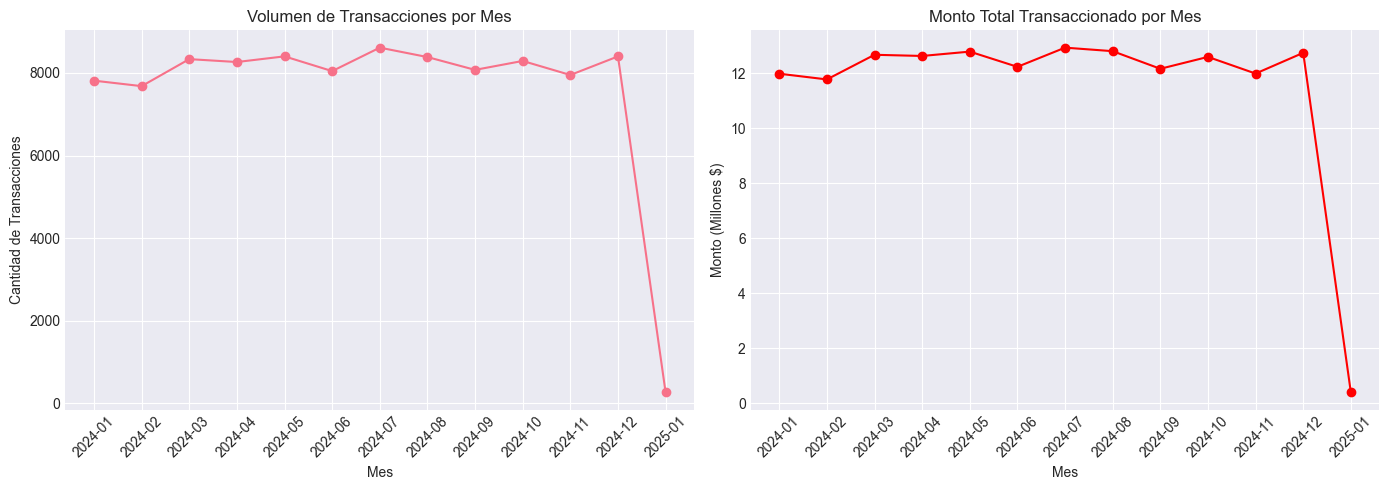

In [25]:
# Análisis de transacciones

print("\n Análisis de transacciones")

# Limpiar fechas por posibles errores.
# - Formato 1: 'DD/MM/AAAA' (ej: 25/12/2023) - con slash
# - Formato 2: 'AAAA-MM-DD' (ej: 2023-12-25) - con guiones
# Esta función detecta automáticamente cuál es y lo convierte a datetime
def parse_fecha(fecha):
    """Convierte fechas en diferentes formatos a datetime"""
    try:
        if isinstance(fecha, str):
            if '/' in fecha:
                # Formato: 25/12/2023 (latinoamericano/europeo)
                return datetime.strptime(fecha, '%d/%m/%Y')
            else:
                # Formato: 2023-12-25 (ISO/americano)
                return datetime.strptime(fecha, '%Y-%m-%d')
        return fecha
    except:
        # Si falla todo, marca como fecha inválida (NaN)
        return pd.NaT


# Aplicar limpieza
# Crea columna con fechas ya convertidas a formato datetime
transacciones.loc[:,'fecha_clean'] = transacciones['fecha'].apply(parse_fecha)

# Extrae el año-mes de cada fecha (ej: 2023-12) para agrupar por mes
transacciones.loc[:,'mes'] = transacciones['fecha_clean'].dt.to_period('M')

# Estadísticas generales
print("\nEstadísticas de montos:")
display(transacciones['monto'].describe())

# Detección de errores 
# :,. -> Formato de número con comas de miles (ej: 1,234 en vez de 1234)
# .isna().sum()	Cuenta celdas vacías (NaN) en 'canal'
print(f"\nValores nulos en canal: {transacciones['canal'].isna().sum():,}")
# (monto < 0).sum()	Cuenta montos negativos (crea máscara True/False y suma)
print(f"Transacciones con monto negativo: {(transacciones['monto'] < 0).sum():,}")
# .isna().sum()	Cuenta fechas que no se pudieron convertir (NaT)
print(f"Fechas no parseables: {transacciones['fecha_clean'].isna().sum():,}")

# Distribución por canal (medio de la transacción)

# Gráfico 1 (izquierda): Cantidad de transacciones por cada canal
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
transacciones['canal'].value_counts().plot(kind='bar')
plt.title('Transacciones por Canal')
plt.xlabel('Canal')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)

# Gráfico 2 (derecha): Monto promedio de transacciones por cada canal
# Agrupa por canal y calcula el promedio de montos
plt.subplot(1, 2, 2)
transacciones.groupby('canal')['monto'].mean().plot(kind='bar', color='green')
plt.title('Monto Promedio por Canal')
plt.xlabel('Canal')
plt.ylabel('Monto Promedio ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Evolución temporal: agrupa transacciones por mes
# Calcula dos métricas por cada mes:
# - count: número total de transacciones
# - sum: monto total transaccionado
transacciones_mensuales = transacciones.groupby('mes').agg({
    'transaccion_id': 'count',  # Volumen de transacciones
    'monto': 'sum'               # Dinero total movido
}).reset_index()

# Convierte la columna mes a texto para graficar (los períodos no se grafican bien)
transacciones_mensuales.loc[:,'mes_str'] = transacciones_mensuales['mes'].astype(str)

# Evolución temporal: volumen y monto de transacciones mes a mes
plt.figure(figsize=(14, 5))

# Gráfico 1 (izquierda): Cantidad de transacciones por mes (volumen)
plt.subplot(1, 2, 1)
plt.plot(transacciones_mensuales['mes_str'], transacciones_mensuales['transaccion_id'], marker='o')
plt.title('Volumen de Transacciones por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Transacciones')
plt.xticks(rotation=45)

# Gráfico 2 (derecha): Monto total transaccionado por mes (en millones)
# Dividir entre 1e6 convierte la cifra a millones para mejor visualización
plt.subplot(1, 2, 2)
plt.plot(transacciones_mensuales['mes_str'], transacciones_mensuales['monto']/1e6, marker='o', color='red')
plt.title('Monto Total Transaccionado por Mes')
plt.xlabel('Mes')
plt.ylabel('Monto (Millones $)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Análisis de uso de app/web

Acciones en app:


accion
Login             79627
Consulta Saldo    60249
Pago              19923
Transferencia     19885
Soporte           10159
Inversión         10157
Name: count, dtype: int64


Tiempo promedio por sesión: 914 segundos
Tiempo máximo de sesión: 1799 segundos


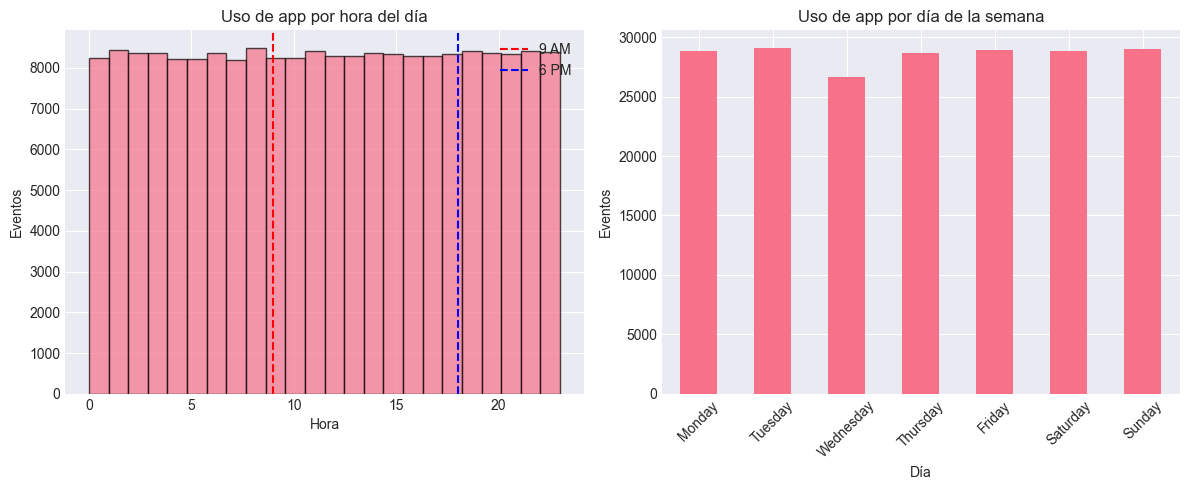

In [36]:
# Análisis de canales digitales
print("\nAnálisis de uso de app/web")

# canales: app/movil, web/online, etc
# Cambiar de formato cada uno de los siguientes datos
canales.loc[:,'fecha_hora'] = pd.to_datetime(canales['fecha_hora'])
canales.loc[:,'fecha'] = canales['fecha_hora'].dt.date
canales.loc[:,'hora'] = canales['fecha_hora'].dt.hour
canales.loc[:,'dia_semana'] = canales['fecha_hora'].dt.day_name()

# Identificar acciones más comúnes.
print("\nAcciones en app:")
display(canales['accion'].value_counts())

# Mostrar tiempo promedio por sesión
# Calcula tiempo de sesión solo para acciones 'Login'
# Filtra: primero [canales['accion']=='Login'] selecciona filas donde accion es Login
# Luego de esas filas, toma la columna 'tiempo_sesion_seg' y calcula promedio o el tiempo máximo
login_sessions = canales[canales['accion'] == 'Login']
tiempos_login = login_sessions['tiempo_sesion_seg']

print(f"\nTiempo promedio por sesión: {tiempos_login.mean():.0f} segundos")
print(f"Tiempo máximo de sesión: {tiempos_login.max():.0f} segundos")

# Distribución por hora
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
# Histograma
canales['hora'].hist(bins=24, edgecolor='black', alpha=0.7)
plt.title('Uso de app por hora del día')
plt.xlabel('Hora')
plt.ylabel('Eventos')
plt.axvline(x=9, color='red', linestyle='--', label='9 AM')
plt.axvline(x=18, color='blue', linestyle='--', label='6 PM')
plt.legend()

plt.subplot(1,2,2)
canales['dia_semana'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).plot(kind='bar')
plt.title('Uso de app por día de la semana')
plt.xlabel('Día')
plt.ylabel('Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# Isights preeliminares
print("\n Insights detectados")

# MVP clients
top_clientes = transacciones.groupby('cliente_id')['monto'].sum().sort_values(ascending=False).head(10)
print(f"\n Top 10 de clientes por monto total en transacciones:")
display(top_clientes)

# uso canal digital vs físico
canales_digitales = ['App Móvil', 'Web']
canales_fisicos = ['Sucursal', 'Cajero']

# Clasificación de canales: crea nueva columna 'tipo_canal' (Digital, Físico u Otro)
# Revisa cada 'canal' y lo clasifica según las listas definidas
transacciones.loc[:, 'tipo_canal'] = transacciones['canal'].apply(
    lambda x: 'Digital' if x in canales_digitales else 'Físico' if x in canales_fisicos else 'Otro')

# Proporción: calcula qué porcentaje de transacciones son Digital vs Físico
digital_vs_fisico = transacciones['tipo_canal'].value_counts()
print(f"\nProporción Digital vs Físico:")
print(f"   Digital: {digital_vs_fisico.get('Digital', 0)/len(transacciones)*100:.1f}%")
print(f"   Físico: {digital_vs_fisico.get('Físico', 0)/len(transacciones)*100:.1f}%")

# 3. Adopción digital por segmento: identifica qué segmento usa más canales digitales
# Paso 1: Filtra solo transacciones digitales y cuenta cuántas hizo cada cliente
transacciones_digitales_por_cliente = transacciones[transacciones['tipo_canal'] == 'Digital'].groupby('cliente_id').size().reset_index(name='transacciones_digitales')

# Combinar con la tabla de clientes para conocer el segmento de cada uno
clientes_transacciones = pd.merge(
    transacciones_digitales_por_cliente,
    clientes[['cliente_id', 'segmento']],
    on='cliente_id'
)

# Calcular el promedio de transacciones digitales por segmento
print(f"\nTransacciones digitales promedio por segmento (ordenado de mayor a menor):")
display(clientes_transacciones.groupby('segmento')['transacciones_digitales'].mean().sort_values(ascending=False))

print("Análisis completo")
print("Insights para el desarrollo del dashboard en Power BI")


 Insights detectados

 Top 10 de clientes por monto total en transacciones:


cliente_id
2228    61307.04
2662    60424.16
327     59814.49
2226    58835.78
1588    56603.68
1027    56206.32
3185    55794.17
2439    55442.67
2635    54958.88
1433    54040.70
Name: monto, dtype: float64


Proporción Digital vs Físico:
   Digital: 49.5%
   Físico: 49.6%

Transacciones digitales promedio por segmento (ordenado de mayor a menor):


segmento
Alto       10.078059
Premium     9.928339
Masivo      9.878930
Medio       9.743243
Name: transacciones_digitales, dtype: float64

Análisis completo
Insights para el desarrollo del dashboard en Power BI
